In [1]:
# Install SHAP (not pre-installed on Kaggle)
!pip install shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from imblearn.over_sampling import SMOTE

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


In [ ]:
df = pd.read_csv('/kaggle/input/datasets/sruthi0304/crop-data/cropdataset.csv')

print('Shape:', df.shape)
print('\nColumn Names:', df.columns.tolist())
df.head()

Shape: (7630, 15)

Column Names: ['Ph', 'K', 'P', 'N', 'Zn', 'S', 'CLOUD_AMT', 'PS', 'temperature_range', 'wind_chill', 'CLOUD0/1', 'temperature_humidity_ratio', 'precipitation', '(WD10M + GWETTOP)/ WS2M_RANGE', 'label']


,Ph,K,P,N,Zn,S,CLOUD_AMT,PS,temperature_range,wind_chill,CLOUD0/1,temperature_humidity_ratio,precipitation,(WD10M + GWETTOP)/ WS2M_RANGE,label
0,5.65,207.086,3.41800,0.23,0.460181,16.075,56.57,77.03,17.330833,20.940904,1,2.511763,6.229167,0.668269,Barley
1,5.57,303.528,2.14700,0.23,1.418000,11.203,56.57,77.03,17.330833,20.940904,1,2.511763,6.229167,0.668269,Barley
2,5.34,401.063,6.38200,0.23,2.433000,13.069,56.57,77.03,17.330833,20.940904,1,2.511763,6.229167,0.668269,Barley
3,5.47,217.874,0.83888,0.23,0.723258,11.880,56.57,77.03,17.330833,20.940904,1,2.511763,6.229167,0.668269,Barley
4,6.06,149.357,1.50500,0.23,0.754669,11.350,56.57,77.03,17.330833,20.940904,1,2.511763,6.229167,0.668269,Barley


In [3]:
# Basic info
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Basic Statistics ===')
df.describe()

=== Data Types ===
Ph                               float64
K                                float64
P                                float64
N                                float64
Zn                               float64
S                                float64
CLOUD_AMT                        float64
PS                               float64
temperature_range                float64
wind_chill                       float64
CLOUD0/1                           int64
temperature_humidity_ratio       float64
precipitation                    float64
(WD10M + GWETTOP)/ WS2M_RANGE    float64
label                             object
dtype: object

=== Missing Values ===
Ph                               0
K                                0
P                                0
N                                0
Zn                               0
S                                0
CLOUD_AMT                        0
PS                               0
temperature_range                0
wind_chill   

,Ph,K,P,N,Zn,S,CLOUD_AMT,PS,temperature_range,wind_chill,CLOUD0/1,temperature_humidity_ratio,precipitation,(WD10M + GWETTOP)/ WS2M_RANGE
count,7630.000000,7630.000000,7630.000000,7630.000000,7630.000000,7630.000000,7630.000000,7630.000000,7630.000000,7630.000000,7630.0,7630.000000,7630.000000,7630.000000
mean,5.850688,254.184641,4.494438,0.177793,1.373208,10.681493,58.830017,77.608488,16.289046,4.709161,1.0,2.490572,6.940918,10.242355
std,0.517026,116.174524,3.152173,0.059550,0.463180,4.609618,0.979883,0.677094,0.380913,4.644414,0.0,0.092280,1.086870,3.843834
min,4.300000,42.000000,0.000000,0.005078,0.100000,0.050000,52.958130,76.067934,15.320671,-3.225545,1.0,2.393040,4.096203,0.545661
25%,5.444449,164.176152,2.000000,0.133300,1.024421,7.177277,59.110000,77.183160,16.091169,1.625920,1.0,2.427191,6.131521,6.807763
50%,5.796341,242.028893,3.491721,0.176823,1.319029,9.838406,59.110000,77.345768,16.300000,3.140940,1.0,2.438447,7.538333,11.620808
75%,6.150057,330.754594,6.142236,0.226427,1.640000,13.406323,59.110000,78.250000,16.608759,6.740509,1.0,2.537305,7.645000,13.233249
max,7.205342,650.942305,14.829690,0.361886,2.850000,23.578696,59.110000,80.094946,17.490339,25.406583,1.0,2.776815,8.598842,24.257631


=== Crop Distribution ===
label
Fallow        893
Wheat         822
Barley        787
Bean          786
Pea           781
Niger seed    650
Sorghum       640
Teff          625
Red Pepper    564
Potato        485
Maize         344
Dagussa       253
Name: count, dtype: int64


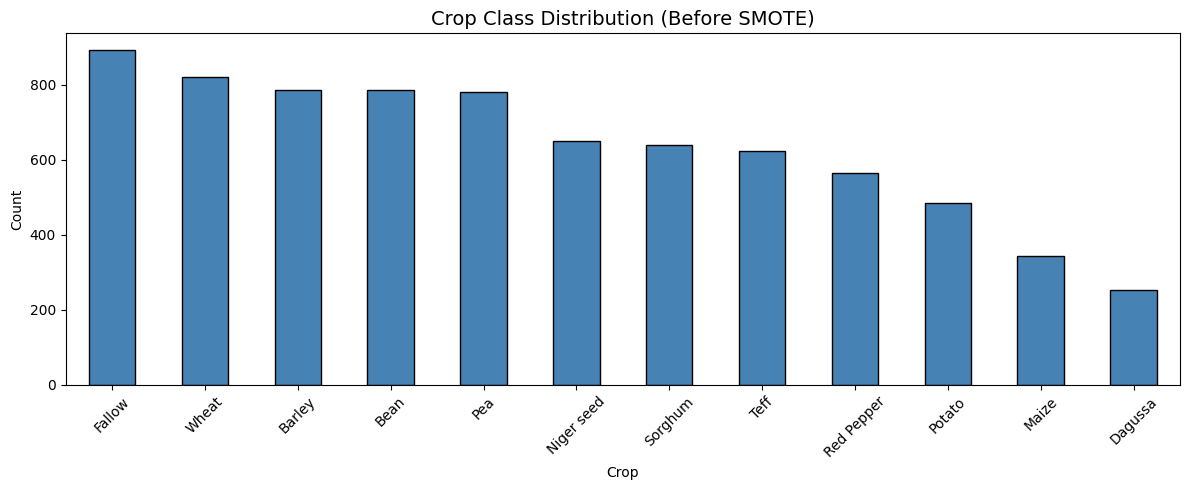

📸 Save this chart — use it in your paper (Figure 1)


In [ ]:
# Class distribution
print('=== Crop Distribution ===')
print(df['label'].value_counts())

plt.figure(figsize=(12, 5))
df['label'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Crop Class Distribution (Before SMOTE)', fontsize=14)
plt.xlabel('Crop')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('class_distribution_before.png', dpi=150)
plt.show()

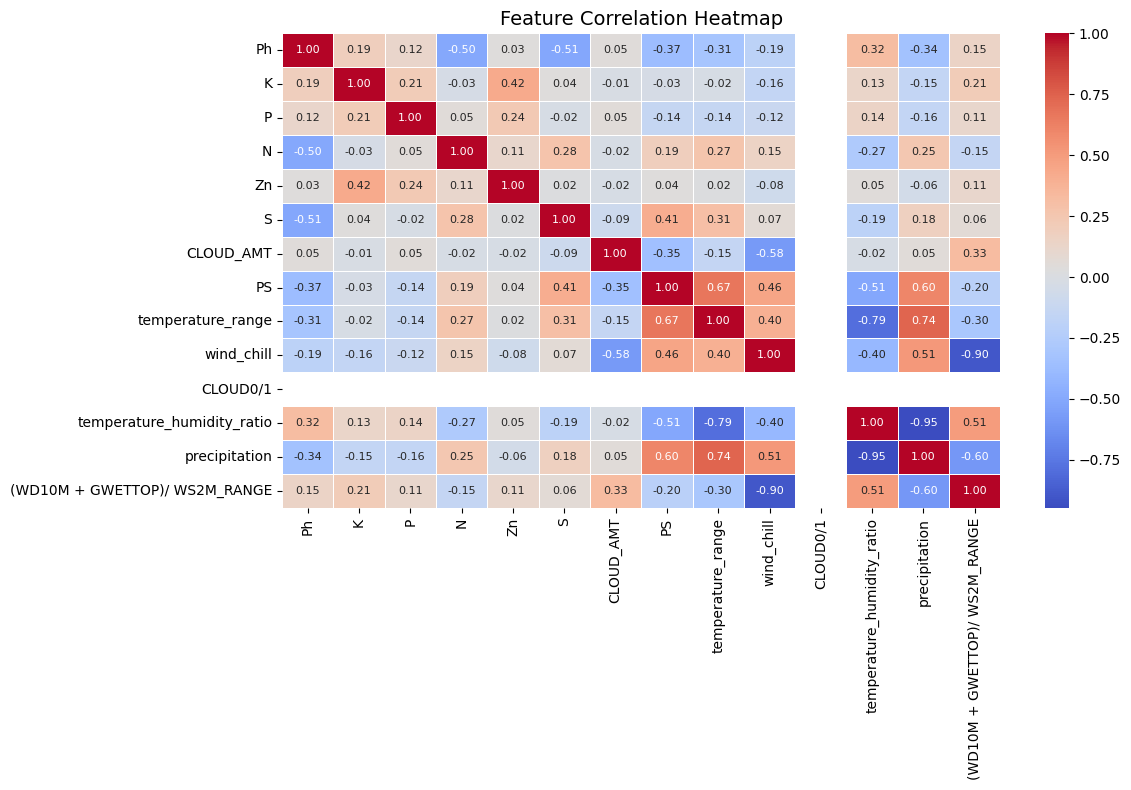

📸 Save this chart — use it in your paper (Figure 2)


In [5]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print('📸 Save this chart — use it in your paper (Figure 2)')

## ⚙️ Phase 2 — Preprocessing

In [6]:
# Rename messy column name for ease
df.rename(columns={'(WD10M + GWETTOP)/ WS2M_RANGE': 'wind_soil_ratio'}, inplace=True)

# Separate features and target
X = df.drop('label', axis=1)
y = df['label']

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print('Classes:', le.classes_)
print('Encoded:', np.unique(y_encoded))

Classes: ['Barley' 'Bean' 'Dagussa' 'Fallow' 'Maize' 'Niger seed' 'Pea' 'Potato'
 'Red Pepper' 'Sorghum' 'Teff' 'Wheat']
Encoded: [ 0  1  2  3  4  5  6  7  8  9 10 11]


In [7]:
# Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y_encoded)

print('Before SMOTE:', X.shape)
print('After SMOTE: ', X_resampled.shape)

# Show new distribution
from collections import Counter
dist_after = Counter(y_resampled)
dist_labels = {le.classes_[k]: v for k, v in dist_after.items()}
print('\nClass Distribution After SMOTE:')
for crop, count in sorted(dist_labels.items()):
    print(f'  {crop}: {count}')

Before SMOTE: (7630, 14)
After SMOTE:  (10716, 14)

Class Distribution After SMOTE:
  Barley: 893
  Bean: 893
  Dagussa: 893
  Fallow: 893
  Maize: 893
  Niger seed: 893
  Pea: 893
  Potato: 893
  Red Pepper: 893
  Sorghum: 893
  Teff: 893
  Wheat: 893


In [8]:
# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set: {X_train_scaled.shape}')
print(f'Test set:     {X_test_scaled.shape}')

Training set: (8572, 14)
Test set:     (2144, 14)


## 🤖 Phase 3 — Train & Evaluate All ML Models

In [9]:
# Helper function to evaluate any model
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted')
    rec  = recall_score(y_te, y_pred, average='weighted')
    f1   = f1_score(y_te, y_pred, average='weighted')
    
    print(f'\n{'='*50}')
    print(f'  {name}')
    print(f'{'='*50}')
    print(f'  Accuracy : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall   : {rec:.4f}')
    print(f'  F1-Score : {f1:.4f}')
    
    return model, y_pred, {'Model': name, 'Accuracy': round(acc*100,2),
                            'Precision': round(prec*100,2), 'Recall': round(rec*100,2),
                            'F1-Score': round(f1*100,2)}

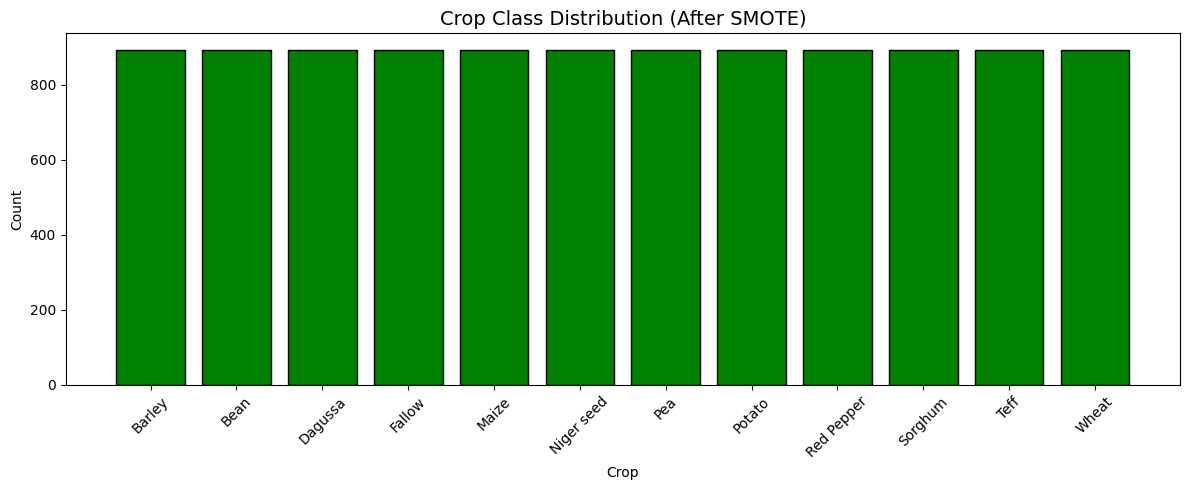

In [10]:
# Class distribution AFTER SMOTE
import matplotlib.pyplot as plt
from collections import Counter

dist_after = Counter(y_resampled)
dist_labels = {le.classes_[k]: v for k, v in dist_after.items()}

plt.figure(figsize=(12, 5))
plt.bar(dist_labels.keys(), dist_labels.values(), color='green', edgecolor='black')
plt.title('Crop Class Distribution (After SMOTE)', fontsize=14)
plt.xlabel('Crop')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('class_distribution_after.png', dpi=150)
plt.show()

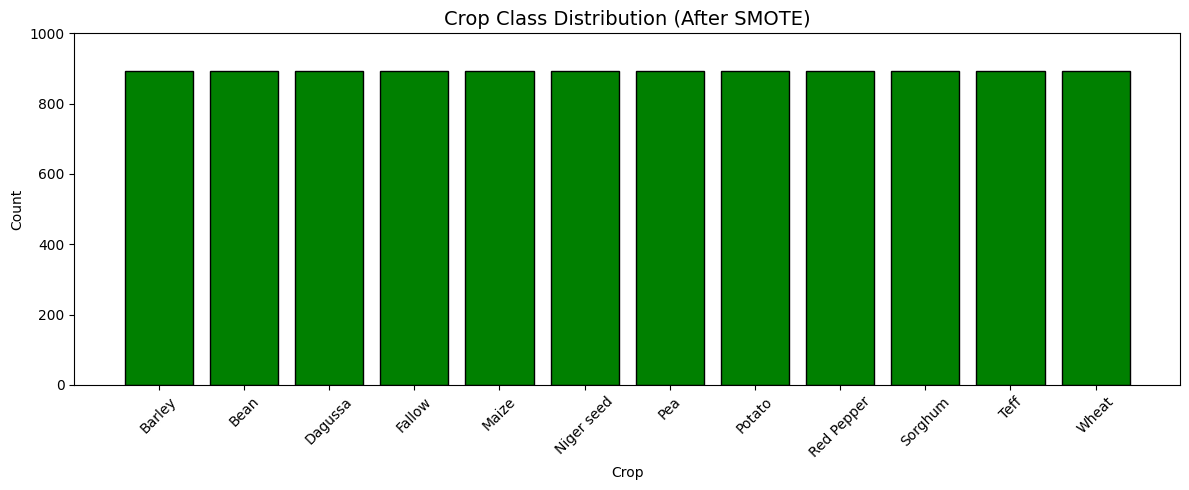

📸 Save this — After SMOTE chart


In [11]:
from collections import Counter
dist_after = Counter(y_resampled)
dist_labels = {le.classes_[k]: v for k, v in dist_after.items()}

plt.figure(figsize=(12, 5))
plt.bar(dist_labels.keys(), dist_labels.values(), 
        color='green', edgecolor='black')
plt.title('Crop Class Distribution (After SMOTE)', fontsize=14)
plt.xlabel('Crop')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.ylim(0, 1000)
plt.tight_layout()
plt.savefig('class_distribution_after.png', dpi=150)
plt.show()
print('📸 Save this — After SMOTE chart')

In [12]:
# 1️⃣ Decision Tree
dt_model, dt_pred, dt_results = evaluate_model(
    'Decision Tree',
    DecisionTreeClassifier(random_state=42, max_depth=20),
    X_train_scaled, X_test_scaled, y_train, y_test
)


  Decision Tree
  Accuracy : 0.7575  (75.75%)
  Precision: 0.7524
  Recall   : 0.7575
  F1-Score : 0.7541


In [13]:
# 2️⃣ Random Forest
rf_model, rf_pred, rf_results = evaluate_model(
    'Random Forest',
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_train_scaled, X_test_scaled, y_train, y_test
)


  Random Forest
  Accuracy : 0.8433  (84.33%)
  Precision: 0.8368
  Recall   : 0.8433
  F1-Score : 0.8384


In [14]:
# 3️⃣ Support Vector Machine
svm_model, svm_pred, svm_results = evaluate_model(
    'Support Vector Machine',
    SVC(kernel='rbf', C=1.0, random_state=42),
    X_train_scaled, X_test_scaled, y_train, y_test
)


  Support Vector Machine
  Accuracy : 0.6553  (65.53%)
  Precision: 0.6377
  Recall   : 0.6553
  F1-Score : 0.6370


In [15]:
# 4️⃣ Gradient Boosting
gb_model, gb_pred, gb_results = evaluate_model(
    'Gradient Boosting',
    GradientBoostingClassifier(n_estimators=100, random_state=42),
    X_train_scaled, X_test_scaled, y_train, y_test
)


  Gradient Boosting
  Accuracy : 0.7127  (71.27%)
  Precision: 0.6993
  Recall   : 0.7127
  F1-Score : 0.7024



=== MODEL COMPARISON TABLE ===
                 Model  Accuracy  Precision  Recall  F1-Score
         Random Forest     84.33      83.68   84.33     83.84
         Decision Tree     75.75      75.24   75.75     75.41
     Gradient Boosting     71.27      69.93   71.27     70.24
Support Vector Machine     65.53      63.77   65.53     63.70


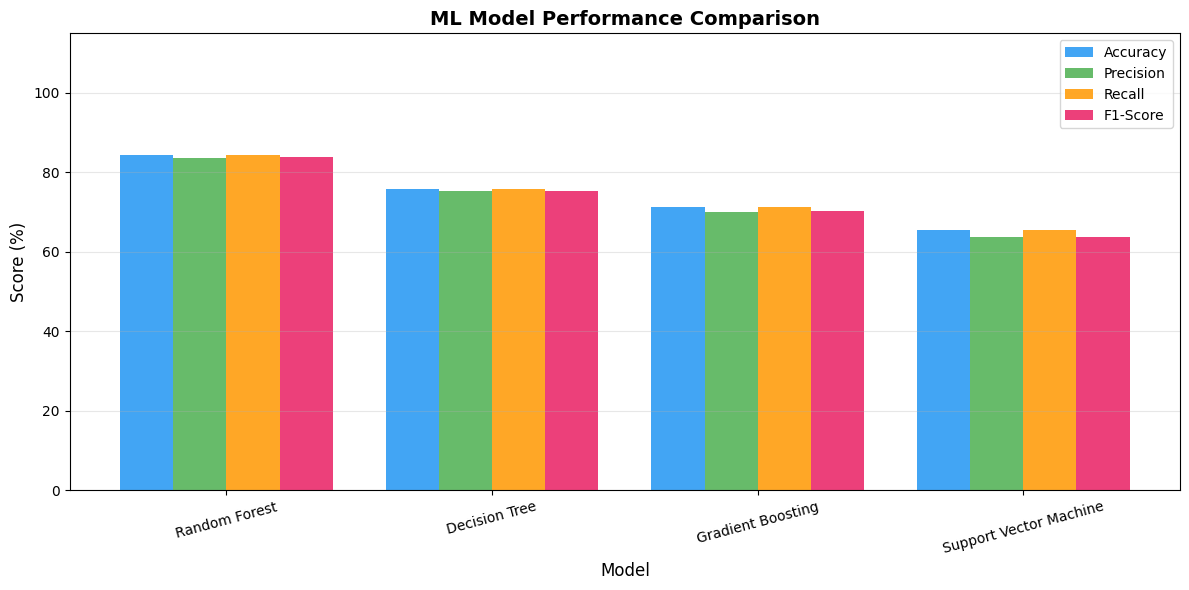

📸 Save this chart — use it in your paper (Figure 3)


In [16]:
# 📊 Comparison Table — COPY THIS INTO YOUR PAPER
results_df = pd.DataFrame([dt_results, rf_results, svm_results, gb_results])
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print('\n=== MODEL COMPARISON TABLE ===')
print(results_df.to_string(index=False))

# Plot comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(results_df))
width = 0.2
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i*width, results_df[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('ML Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(results_df['Model'], rotation=15)
ax.legend()
ax.set_ylim(0, 115)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print('📸 Save this chart — use it in your paper (Figure 3)')

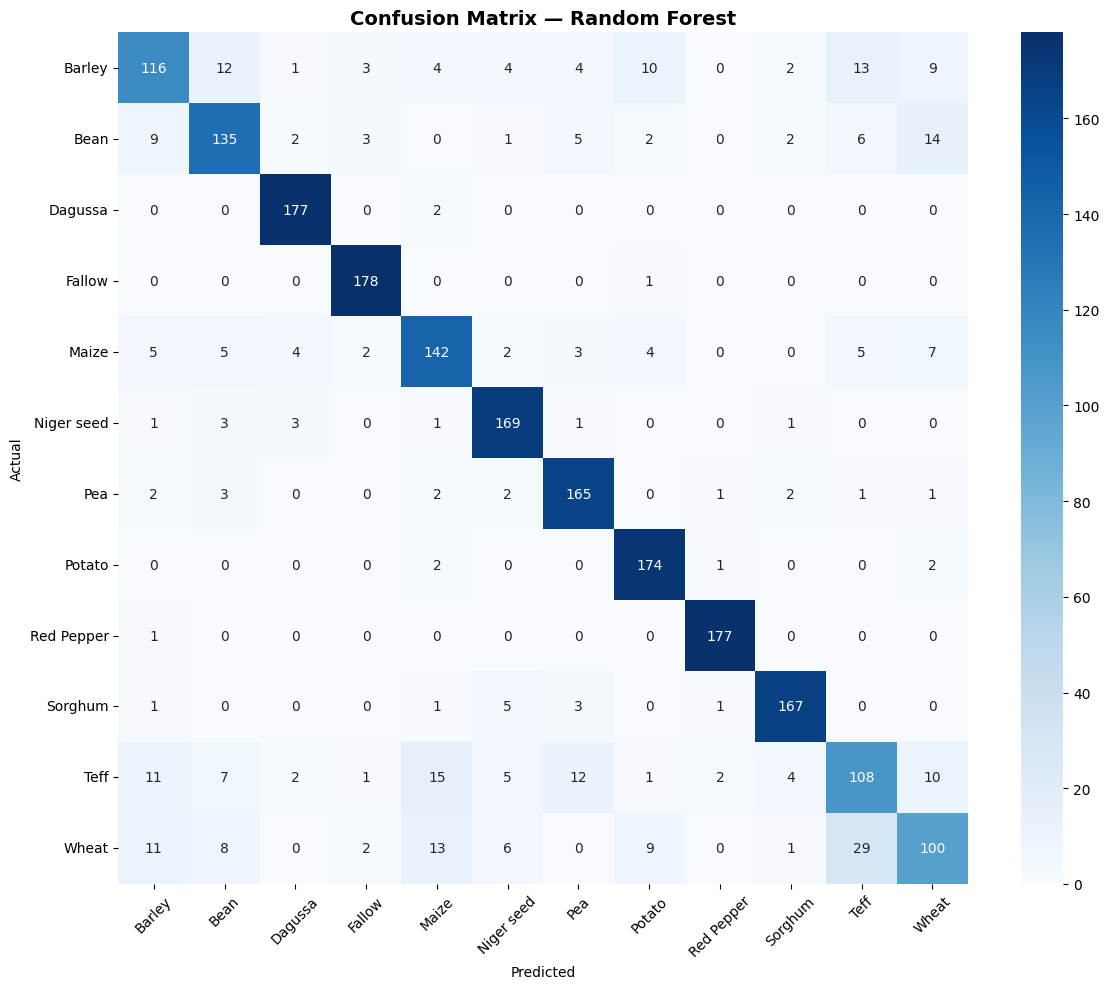

📸 Save this chart — use it in your paper (Figure 4)


In [17]:
# Confusion Matrix for Best Model (Random Forest expected)
best_pred = rf_pred  # Change if another model wins
best_name = 'Random Forest'

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix — {best_name}', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('📸 Save this chart — use it in your paper (Figure 4)')

## 🔍 Phase 4 — Explainability (SHAP)

In [18]:
# SHAP for Random Forest (best model)
print('Computing SHAP values... (this may take 1-2 minutes)')
explainer = shap.TreeExplainer(rf_model)

# Use a sample for speed
X_test_sample = pd.DataFrame(X_test_scaled[:200], columns=X.columns)
shap_values = explainer.shap_values(X_test_sample)

print('✅ SHAP values computed!')

Computing SHAP values... (this may take 1-2 minutes)
✅ SHAP values computed!


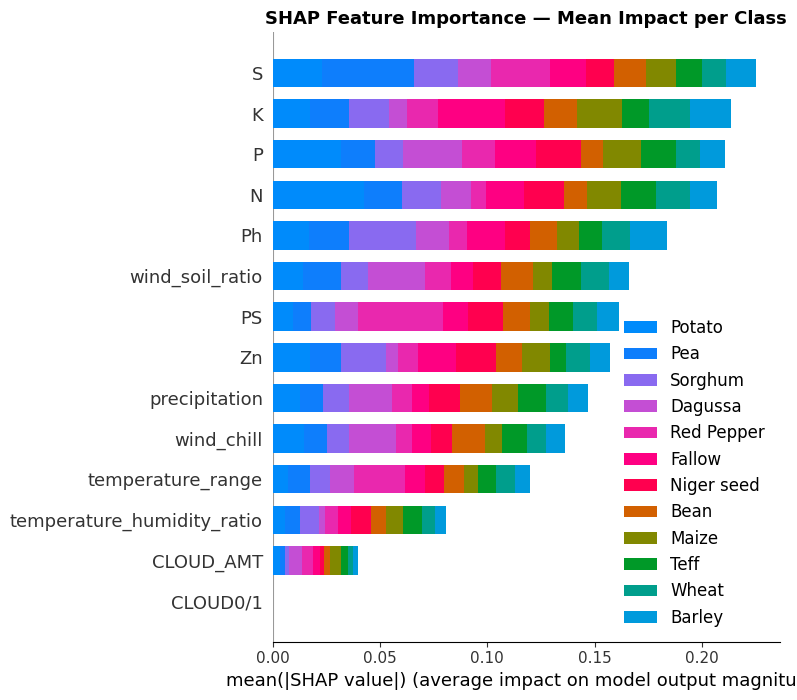

📸 Save this chart — use it in your paper (Figure 5)


In [19]:
# SHAP Summary Plot (Beeswarm)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_sample, plot_type='bar',
                  class_names=le.classes_, show=False)
plt.title('SHAP Feature Importance — Mean Impact per Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('📸 Save this chart — use it in your paper (Figure 5)')

=== FEATURE IMPORTANCE RANKING ===
                   Feature  Importance
                         K    0.159731
                         S    0.128065
                         P    0.116689
                         N    0.111320
                        Zn    0.109576
                        Ph    0.104247
                        PS    0.048154
           wind_soil_ratio    0.048059
             precipitation    0.044352
         temperature_range    0.043594
                wind_chill    0.042377
temperature_humidity_ratio    0.034571
                 CLOUD_AMT    0.009265
                  CLOUD0/1    0.000000


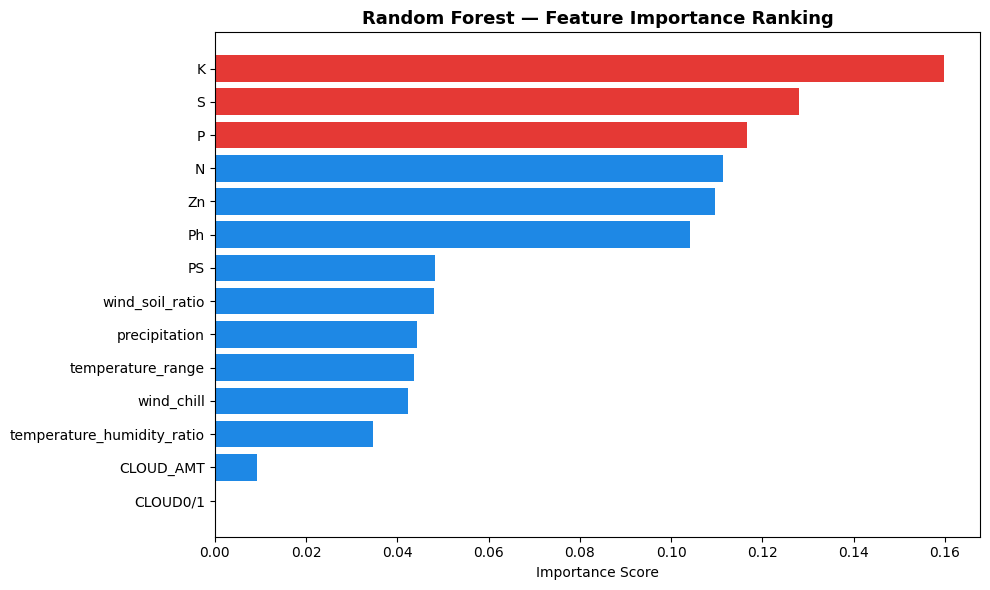

📸 Save this chart — use it in your paper (Figure 6)

⭐ Top 3 most important features (mention in paper):
Feature  Importance
      K    0.159731
      S    0.128065
      P    0.116689


In [20]:
# Overall feature importance from Random Forest
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print('=== FEATURE IMPORTANCE RANKING ===')
print(feat_imp.to_string(index=False))

plt.figure(figsize=(10, 6))
colors_imp = ['#E53935' if i < 3 else '#1E88E5' for i in range(len(feat_imp))]
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors_imp)
plt.xlabel('Importance Score')
plt.title('Random Forest — Feature Importance Ranking', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print('📸 Save this chart — use it in your paper (Figure 6)')
print('\n⭐ Top 3 most important features (mention in paper):')
print(feat_imp.head(3)[['Feature', 'Importance']].to_string(index=False))

## 🌡️ Phase 5 — Climate Resilience Testing ⭐ (Novel Contribution)

In [21]:
# Original test data (unscaled) for perturbation
X_test_orig = pd.DataFrame(
    scaler.inverse_transform(X_test_scaled),
    columns=X.columns
)

def perturb_and_evaluate(model, scaler, X_orig, y_true, perturbations, model_name):
    """
    Perturb environmental features and measure accuracy change.
    perturbations: dict of {feature_col: delta_value}
    """
    X_perturbed = X_orig.copy()
    for col, delta in perturbations.items():
        if col in X_perturbed.columns:
            X_perturbed[col] = X_perturbed[col] + delta
    
    X_perturbed_scaled = scaler.transform(X_perturbed)
    y_pred = model.predict(X_perturbed_scaled)
    acc = accuracy_score(y_true, y_pred)
    return round(acc * 100, 2)

# Baseline accuracy
baseline_acc = round(accuracy_score(y_test, rf_pred) * 100, 2)
print(f'Baseline Accuracy (No Perturbation): {baseline_acc}%')

Baseline Accuracy (No Perturbation): 84.33%


In [22]:
# Define perturbation scenarios
scenarios = [
    ('Baseline',                    {}),
    ('Temp +2°C',                   {'temperature_range': +2.0}),
    ('Temp -2°C',                   {'temperature_range': -2.0}),
    ('Rainfall +5%',                {'precipitation': +0.05}),
    ('Rainfall -5%',                {'precipitation': -0.05}),
    ('Wind Chill +3%',              {'wind_chill': +0.03}),
    ('Wind Chill -3%',              {'wind_chill': -0.03}),
    ('Temp+2 & Rain+5%',            {'temperature_range': +2.0, 'precipitation': +0.05}),
    ('Temp-2 & Rain-5%',            {'temperature_range': -2.0, 'precipitation': -0.05}),
    ('All Params +Combined',        {'temperature_range': +2.0, 'precipitation': +0.05, 'wind_chill': +0.03}),
    ('All Params -Combined',        {'temperature_range': -2.0, 'precipitation': -0.05, 'wind_chill': -0.03}),
]

# Run for all 4 models
models_to_test = [
    ('Decision Tree',    dt_model),
    ('Random Forest',    rf_model),
    ('SVM',              svm_model),
    ('Gradient Boosting',gb_model),
]

resilience_results = []

for scenario_name, perturbations in scenarios:
    row = {'Scenario': scenario_name}
    for model_name, model in models_to_test:
        if scenario_name == 'Baseline':
            acc = round(accuracy_score(y_test, model.predict(X_test_scaled)) * 100, 2)
        else:
            acc = perturb_and_evaluate(model, scaler, X_test_orig, y_test,
                                        perturbations, model_name)
        row[model_name] = acc
    resilience_results.append(row)

resilience_df = pd.DataFrame(resilience_results)
print('=== CLIMATE RESILIENCE TABLE ===')
print(resilience_df.to_string(index=False))
print('\n📋 COPY THIS TABLE INTO YOUR PAPER')

=== CLIMATE RESILIENCE TABLE ===
            Scenario  Decision Tree  Random Forest   SVM  Gradient Boosting
            Baseline          75.75          84.33 65.53              71.27
           Temp +2°C          66.32          83.54  9.70              60.40
           Temp -2°C          65.25          83.96  9.33              49.63
        Rainfall +5%          74.72          83.82 65.58              69.68
        Rainfall -5%          72.48          83.63 65.67              70.24
      Wind Chill +3%          75.79          84.24 65.53              71.04
      Wind Chill -3%          75.75          84.24 65.49              71.22
    Temp+2 & Rain+5%          65.53          83.40  9.70              61.19
    Temp-2 & Rain-5%          62.17          83.21  9.24              48.27
All Params +Combined          65.58          83.21  9.70              61.33
All Params -Combined          62.13          82.65  9.24              48.18

📋 COPY THIS TABLE INTO YOUR PAPER


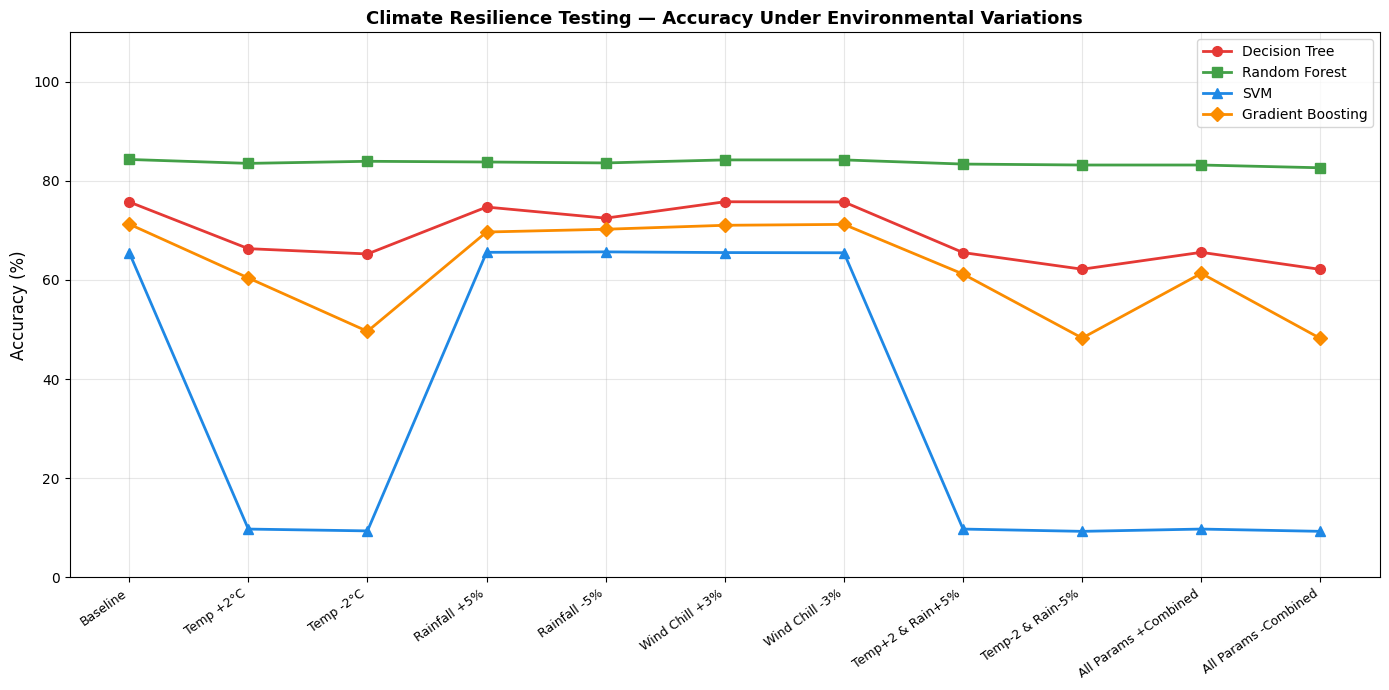

📸 Save this chart — use it in your paper (Figure 7 — your NOVEL CONTRIBUTION)


In [23]:
# Plot Climate Resilience
fig, ax = plt.subplots(figsize=(14, 7))
model_names = ['Decision Tree', 'Random Forest', 'SVM', 'Gradient Boosting']
colors_r = ['#E53935', '#43A047', '#1E88E5', '#FB8C00']
markers = ['o', 's', '^', 'D']

x_labels = resilience_df['Scenario']
x_pos = np.arange(len(x_labels))

for model_name, color, marker in zip(model_names, colors_r, markers):
    ax.plot(x_pos, resilience_df[model_name], marker=marker,
            label=model_name, color=color, linewidth=2, markersize=7)

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Climate Resilience Testing — Accuracy Under Environmental Variations',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(0, 110)
plt.tight_layout()
plt.savefig('climate_resilience.png', dpi=150)
plt.show()
print('📸 Save this chart — use it in your paper (Figure 7 — your NOVEL CONTRIBUTION)')

In [24]:
# Accuracy Drop Analysis
print('=== ACCURACY DROP FROM BASELINE ===')
baseline_row = resilience_df[resilience_df['Scenario'] == 'Baseline'].iloc[0]
for _, row in resilience_df.iterrows():
    if row['Scenario'] == 'Baseline':
        continue
    print(f"\n  {row['Scenario']}:")
    for model_name in model_names:
        drop = baseline_row[model_name] - row[model_name]
        print(f"    {model_name}: {row[model_name]}% (drop: {drop:+.2f}%)")

=== ACCURACY DROP FROM BASELINE ===

  Temp +2°C:
    Decision Tree: 66.32% (drop: +9.43%)
    Random Forest: 83.54% (drop: +0.79%)
    SVM: 9.7% (drop: +55.83%)
    Gradient Boosting: 60.4% (drop: +10.87%)

  Temp -2°C:
    Decision Tree: 65.25% (drop: +10.50%)
    Random Forest: 83.96% (drop: +0.37%)
    SVM: 9.33% (drop: +56.20%)
    Gradient Boosting: 49.63% (drop: +21.64%)

  Rainfall +5%:
    Decision Tree: 74.72% (drop: +1.03%)
    Random Forest: 83.82% (drop: +0.51%)
    SVM: 65.58% (drop: -0.05%)
    Gradient Boosting: 69.68% (drop: +1.59%)

  Rainfall -5%:
    Decision Tree: 72.48% (drop: +3.27%)
    Random Forest: 83.63% (drop: +0.70%)
    SVM: 65.67% (drop: -0.14%)
    Gradient Boosting: 70.24% (drop: +1.03%)

  Wind Chill +3%:
    Decision Tree: 75.79% (drop: -0.04%)
    Random Forest: 84.24% (drop: +0.09%)
    SVM: 65.53% (drop: +0.00%)
    Gradient Boosting: 71.04% (drop: +0.23%)

  Wind Chill -3%:
    Decision Tree: 75.75% (drop: +0.00%)
    Random Forest: 84.24% (drop:

In [25]:
from sklearn.metrics import classification_report
report = classification_report(y_test, rf_pred, 
         target_names=le.classes_, output_dict=True)
report_df = pd.DataFrame(report).transpose()
print('=== PER-CLASS PERFORMANCE (Random Forest) ===')
print(report_df.round(4).to_string())

=== PER-CLASS PERFORMANCE (Random Forest) ===
              precision  recall  f1-score    support
Barley           0.7389  0.6517    0.6925   178.0000
Bean             0.7803  0.7542    0.7670   179.0000
Dagussa          0.9365  0.9888    0.9620   179.0000
Fallow           0.9418  0.9944    0.9674   179.0000
Maize            0.7802  0.7933    0.7867   179.0000
Niger seed       0.8711  0.9441    0.9062   179.0000
Pea              0.8549  0.9218    0.8871   179.0000
Potato           0.8657  0.9721    0.9158   179.0000
Red Pepper       0.9725  0.9944    0.9833   178.0000
Sorghum          0.9330  0.9382    0.9356   178.0000
Teff             0.6667  0.6067    0.6353   178.0000
Wheat            0.6993  0.5587    0.6211   179.0000
accuracy         0.8433  0.8433    0.8433     0.8433
macro avg        0.8367  0.8432    0.8383  2144.0000
weighted avg     0.8368  0.8433    0.8384  2144.0000


In [26]:
from sklearn.model_selection import cross_val_score

print('Running 5-fold CV... (may take 2-3 mins)')
cv_scores = cross_val_score(rf_model, X_resampled, 
            y_resampled, cv=5, scoring='accuracy', n_jobs=-1)
print(f'\n=== 5-FOLD CROSS VALIDATION (Random Forest) ===')
print(f'Scores:   {[round(s*100,2) for s in cv_scores]}')
print(f'CV Mean:  {cv_scores.mean()*100:.2f}%')
print(f'CV Std:   {cv_scores.std()*100:.2f}%')

Running 5-fold CV... (may take 2-3 mins)

=== 5-FOLD CROSS VALIDATION (Random Forest) ===
Scores:   [np.float64(75.23), np.float64(83.81), np.float64(83.71), np.float64(85.49), np.float64(87.54)]
CV Mean:  83.16%
CV Std:   4.20%


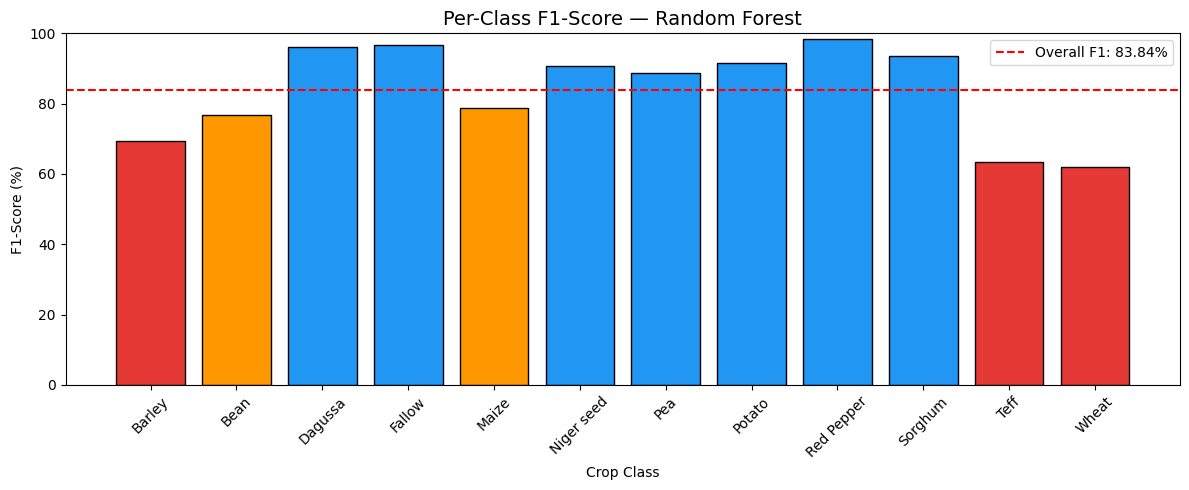

📸 Save this — Per-class F1 chart


In [27]:
# Plot per-class F1 scores
classes = le.classes_
f1_scores = [report[c]['f1-score'] for c in classes]

plt.figure(figsize=(12, 5))
colors = ['#2196F3' if f >= 0.85 else '#FF9800' if f >= 0.70 
          else '#E53935' for f in f1_scores]
plt.bar(classes, [f*100 for f in f1_scores], 
        color=colors, edgecolor='black')
plt.title('Per-Class F1-Score — Random Forest', fontsize=14)
plt.xlabel('Crop Class')
plt.ylabel('F1-Score (%)')
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.axhline(y=83.84, color='red', linestyle='--', 
            label=f'Overall F1: 83.84%')
plt.legend()
plt.tight_layout()
plt.savefig('perclass_f1.png', dpi=150)
plt.show()
print('📸 Save this — Per-class F1 chart')

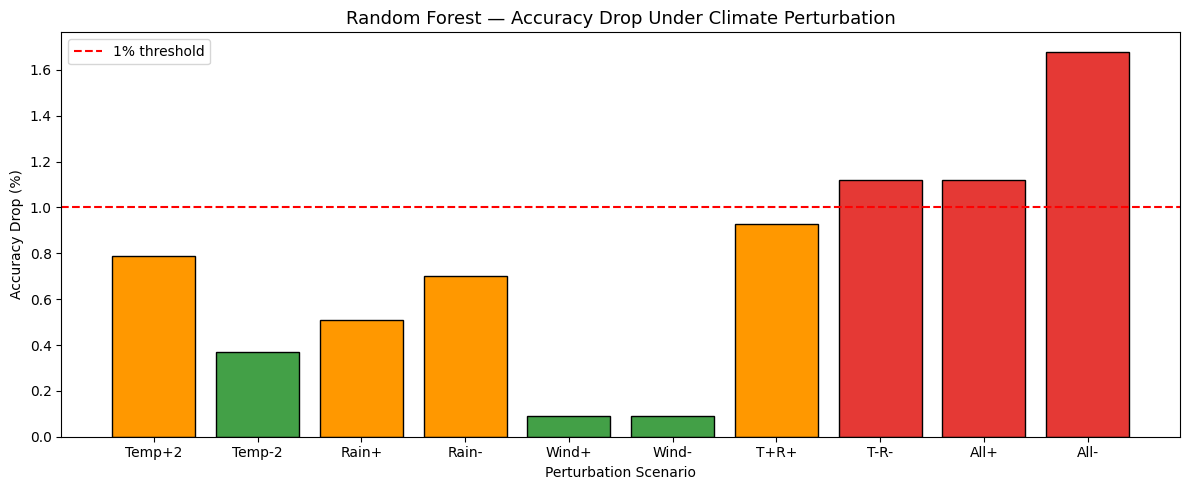

📸 Save this — RF accuracy drop chart


In [28]:
# Clean accuracy drop visualization
scenarios_short = ['Temp+2', 'Temp-2', 'Rain+', 'Rain-', 
                   'Wind+', 'Wind-', 'T+R+', 'T-R-', 
                   'All+', 'All-']
rf_drops = [84.33-83.54, 84.33-83.96, 84.33-83.82, 
            84.33-83.63, 84.33-84.24, 84.33-84.24,
            84.33-83.40, 84.33-83.21, 84.33-83.21, 
            84.33-82.65]

plt.figure(figsize=(12, 5))
bar_colors = ['#E53935' if d > 1.0 else '#FF9800' if d > 0.5 
              else '#43A047' for d in rf_drops]
plt.bar(scenarios_short, rf_drops, color=bar_colors, 
        edgecolor='black')
plt.title('Random Forest — Accuracy Drop Under Climate Perturbation', 
          fontsize=13)
plt.xlabel('Perturbation Scenario')
plt.ylabel('Accuracy Drop (%)')
plt.axhline(y=1.0, color='red', linestyle='--', 
            label='1% threshold')
plt.legend()
plt.tight_layout()
plt.savefig('rf_accuracy_drop.png', dpi=150)
plt.show()
print('📸 Save this — RF accuracy drop chart')

## ✅ Summary — Results to Copy Into Your Paper

After running all cells, collect:

| # | What | Where |
|---|------|-------|
| 1 | Model comparison table | Cell output in Phase 3 |
| 2 | Confusion matrix (best model) | `confusion_matrix.png` |
| 3 | Feature importance ranking | `feature_importance.png` |
| 4 | SHAP summary plot | `shap_summary.png` |
| 5 | Climate resilience table | Cell output in Phase 5 |
| 6 | Climate resilience chart | `climate_resilience.png` |

**Send all of these results back and your conference paper will be generated! 🎓**